In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage

In [35]:
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Clustering\Hierarchical\data\cars_clus.csv",na_values=['Snulls'])
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


In [36]:
df.dtypes

manufact      object
model         object
sales         object
resale        object
type          object
price         object
engine_s      object
horsepow      object
wheelbas      object
width         object
length        object
curb_wgt      object
fuel_cap      object
mpg           object
lnsales       object
partition    float64
dtype: object

In [37]:
df=df.drop(columns=['manufact','model'])

In [38]:
df=df.apply(pd.to_numeric,errors='coerce')
df=df.dropna()
print(df.shape)

(117, 14)


In [39]:
X=df.drop(columns=['partition'])


In [40]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

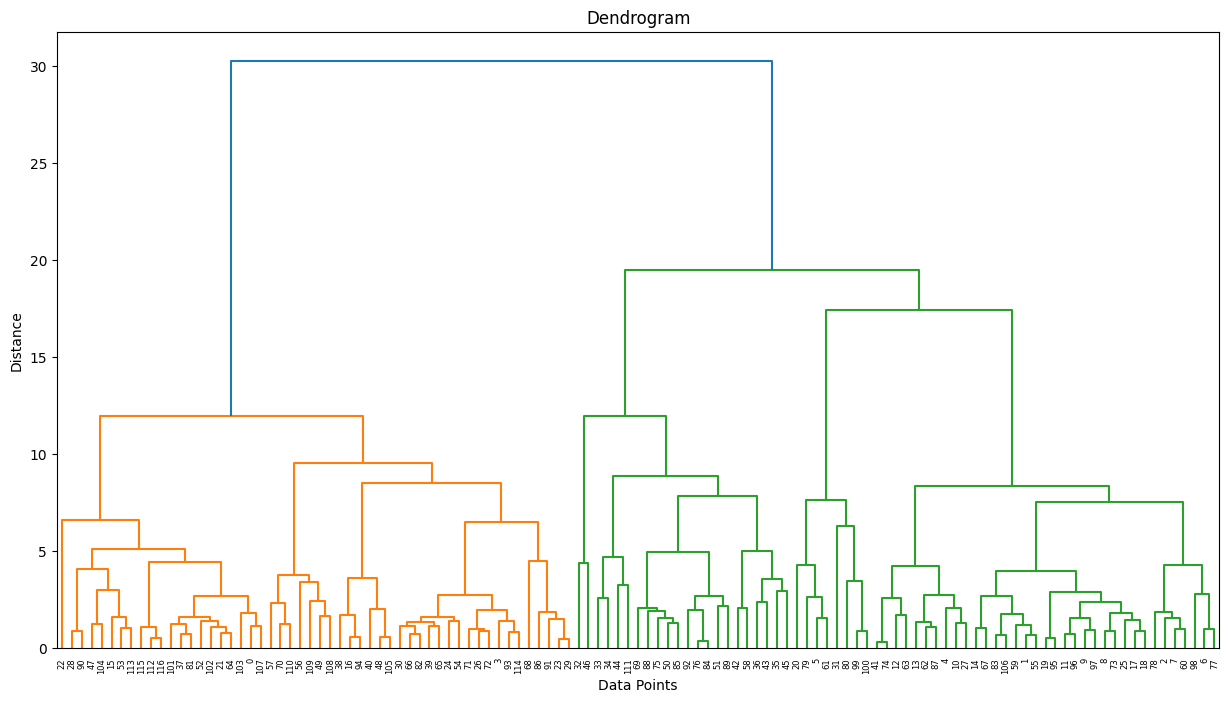

In [41]:
#plot dendrogram
linked=linkage(X_scaled,method='ward')
plt.figure(figsize=(15,8))
dendrogram(linked,
           leaf_rotation=90,
           leaf_font_size=6)
plt.title("Dendrogram")
plt.xlabel('Data Points')
plt.ylabel("Distance")
plt.show()

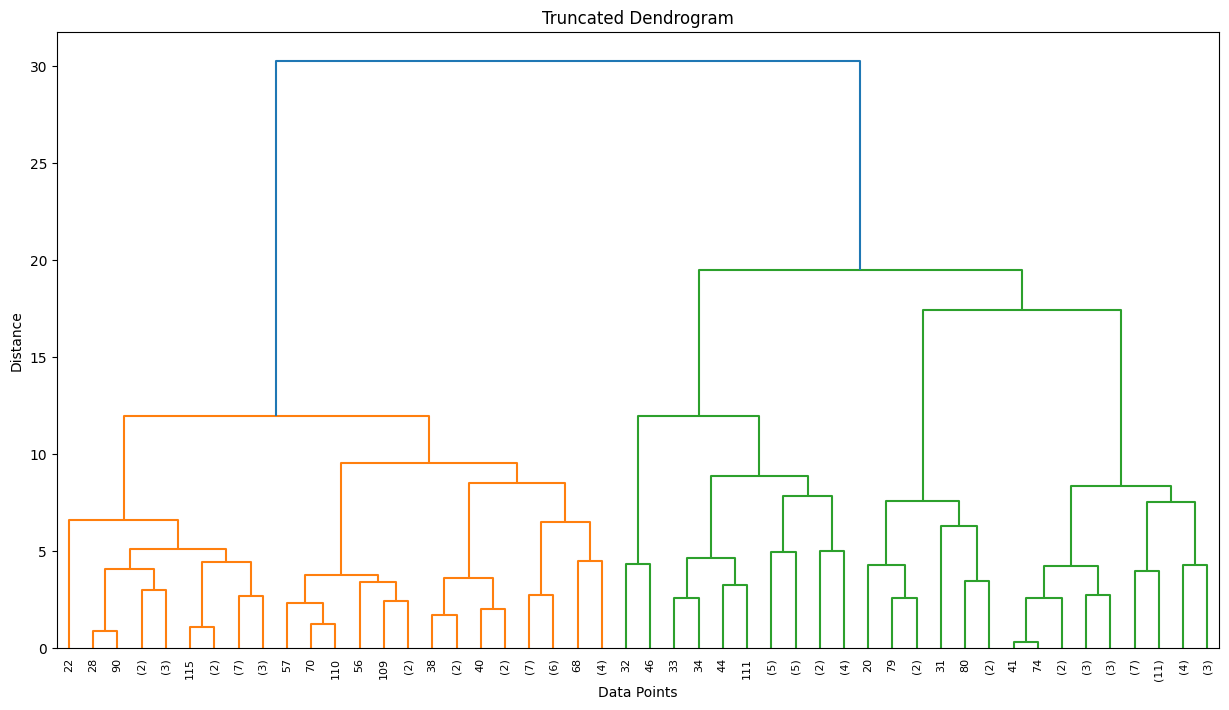

In [42]:

plt.figure(figsize=(15,8))
dendrogram(linked,
           truncate_mode='level',
           p=5
           )
plt.title("Truncated Dendrogram")
plt.xlabel('Data Points')
plt.ylabel("Distance")
plt.show()

In [43]:
print(linked[-5:])

[[220.         227.          11.94932532  52.        ]
 [211.         226.          11.9611578   22.        ]
 [222.         224.          17.39939694  43.        ]
 [229.         230.          19.4680625   65.        ]
 [228.         231.          30.24606656 117.        ]]


In [44]:
print(linked[-1])

[228.         231.          30.24606656 117.        ]


In [48]:
#Dendrogram suggests 2 clusters
#Apply agglomerative clustering
hc=AgglomerativeClustering(n_clusters=2,linkage='ward')
clusters=hc.fit_predict(X_scaled)
df['cluster']=clusters
df.head()

,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition,cluster
0,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0,1
1,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0,0
3,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0,0
4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0,1
5,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0,0


In [49]:
print(X_scaled.shape)

(117, 13)


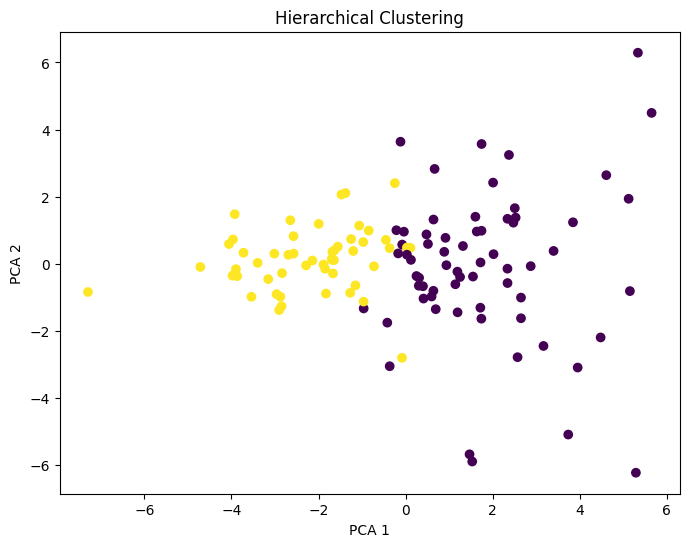

In [50]:
#Visualize clusters
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters)
plt.title("Hierarchical Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()